<a href="https://colab.research.google.com/github/ajaykumar080286/DeepLearning/blob/master/32_cat_vs_dogs_classifications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout,Flatten,MaxPool2D, Conv2D,BatchNormalization

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import zipfile
import requests
import os

# Path to your zip file (URL)
zip_url = "https://github.com/ajaykumar080286/DeepLearning/blob/master/dogs_vs_cats.zip?raw=true"

# Local path to save the downloaded zip file
local_zip_path = "/content/dogs_vs_cats.zip"

# Download the zip file
print(f"Downloading {zip_url} to {local_zip_path}...")
response = requests.get(zip_url)
response.raise_for_status() # Raise an exception for HTTP errors
with open(local_zip_path, 'wb') as f:
    f.write(response.content)
print("Download complete.")

# Open the zip file
zip_ref = zipfile.ZipFile(local_zip_path, 'r')
zip_ref.extractall("/content")
zip_ref.close()
print("Extraction complete.")

# Optionally, remove the downloaded zip file after extraction
os.remove(local_zip_path)

Download complete.
Extraction complete.


In [3]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/dogs_vs_cats/train',
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(256, 256))

val_ds = keras.utils.image_dataset_from_directory(
    directory='/content/dogs_vs_cats/test',
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(256, 256))

Found 23 files belonging to 2 classes.
Found 22 files belonging to 2 classes.


In [4]:
#Normalized

In [5]:
def process(image,label):
  image=tf.cast(image/255, tf.float32)
  return image,label

In [6]:
# Apply your process function
train_ds = train_ds.map(process)
val_ds = val_ds.map(process)


In [7]:
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2), strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2), strides=2,padding='valid'))


model.add(Conv2D(128,kernel_size=(3,3),padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2), strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(2, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,258 (56.64 MB)

 Trainable params: 14,847,810 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=['accuracy'])
history=model.fit(train_ds,epochs=10, validation_data=val_ds)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 0.4783 - loss: 1.6130 - val_accuracy: 0.5000 - val_loss: 2.5588
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.6957 - loss: 16.2404 - val_accuracy: 0.5000 - val_loss: 1.3197
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.9130 - loss: 0.5788 - val_accuracy: 0.5000 - val_loss: 0.8310
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.9565 - loss: 0.4372 - val_accuracy: 0.5909 - val_loss: 0.7443
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.8696 - loss: 0.7100 - val_accuracy: 0.5000 - val_loss: 0.9084
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.9565 - loss: 0.9077 - val_accuracy: 0.5455 - val_loss: 1.1807
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 1.0000 - loss: 8.6556e-07 - val_accuracy: 0.5000 - val_loss: 1.8761
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.9565 - loss: 0.6271 - val_accuracy: 0.5000 - val_loss: 2.3164
Epoch 9/1

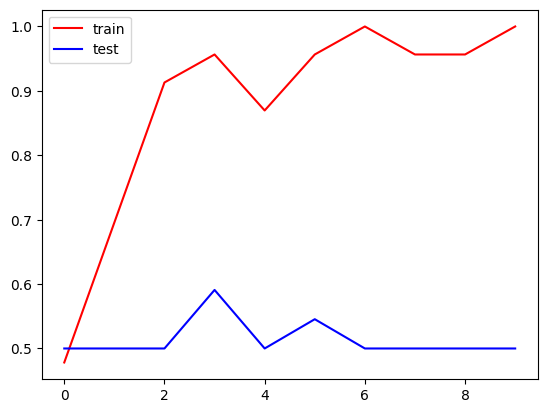

In [10]:
plt.plot(history.history['accuracy'], color='red', label="train")
plt.plot(history.history['val_accuracy'], color='blue', label="test")
plt.legend()

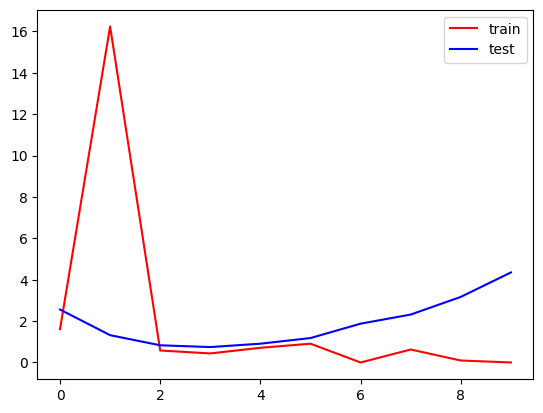

In [11]:
plt.plot(history.history['loss'], color='red', label="train")
plt.plot(history.history['val_loss'], color='blue', label="test")
plt.legend()

In [13]:
import cv2
test_img=cv2.imread("/content/dog.12489.jpg")

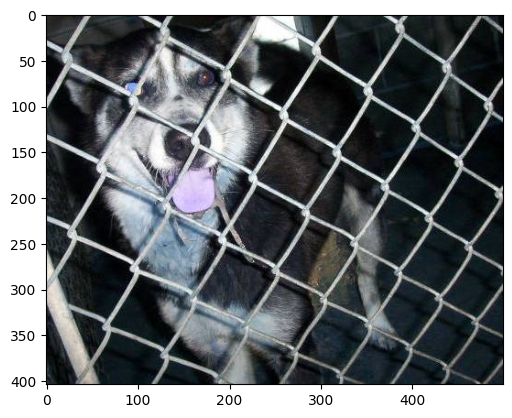

In [14]:
plt.imshow(test_img)

In [15]:
test_img.shape

(404, 499, 3)

In [16]:
test_img=cv2.resize(test_img,(256,256))

In [17]:
test_input=test_img.reshape(1,256,256,3)

In [22]:
model.predict(test_input).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


array([1])

In [23]:
test_img=cv2.imread("/content/cat.7216.jpg")

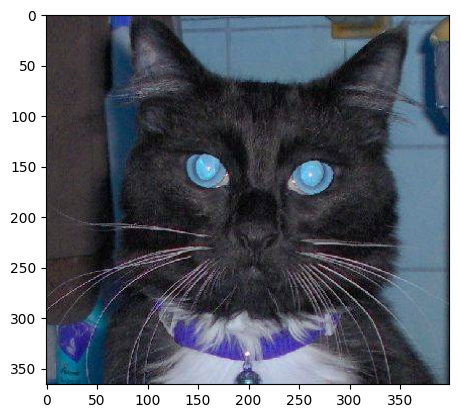

In [24]:
plt.imshow(test_img)

In [25]:
test_img=cv2.resize(test_img,(256,256))

In [26]:
test_input=test_img.reshape(1,256,256,3)

In [28]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


array([[6.2855943e-38, 1.0000000e+00]], dtype=float32)

In [29]:
model.predict(test_input).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


array([1])